<a href="https://colab.research.google.com/github/vidyashiremath/machinelearning/blob/main/Glass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/glass.csv")


In [ ]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
df = df.drop(columns=['RI'])

In [ ]:
plt.figure(figsize=(7, 4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

/tmp/ipykernel_2508/2334631972.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, palette='viridis')


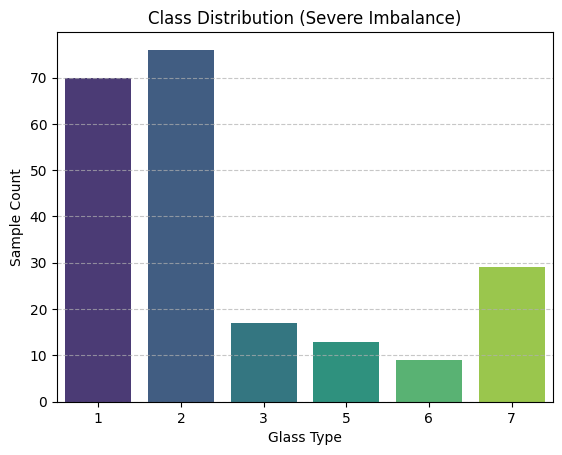

In [ ]:
sns.countplot(x='Type', data=df, palette='viridis')
plt.title("Class Distribution (Severe Imbalance)")
plt.xlabel("Glass Type")
plt.ylabel("Sample Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
plt.figure(figsize=(9, 7))

<Figure size 900x700 with 0 Axes>

<Figure size 900x700 with 0 Axes>

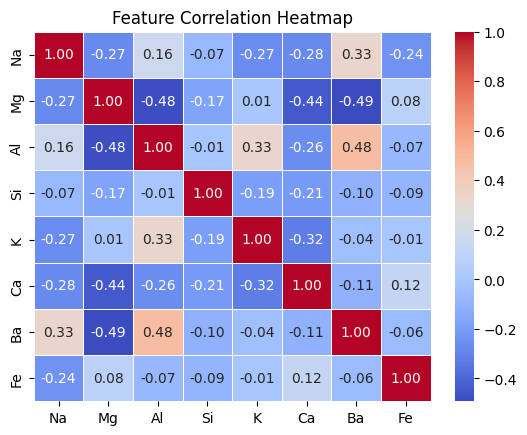

In [ ]:
corr = df.drop(columns=['Type']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

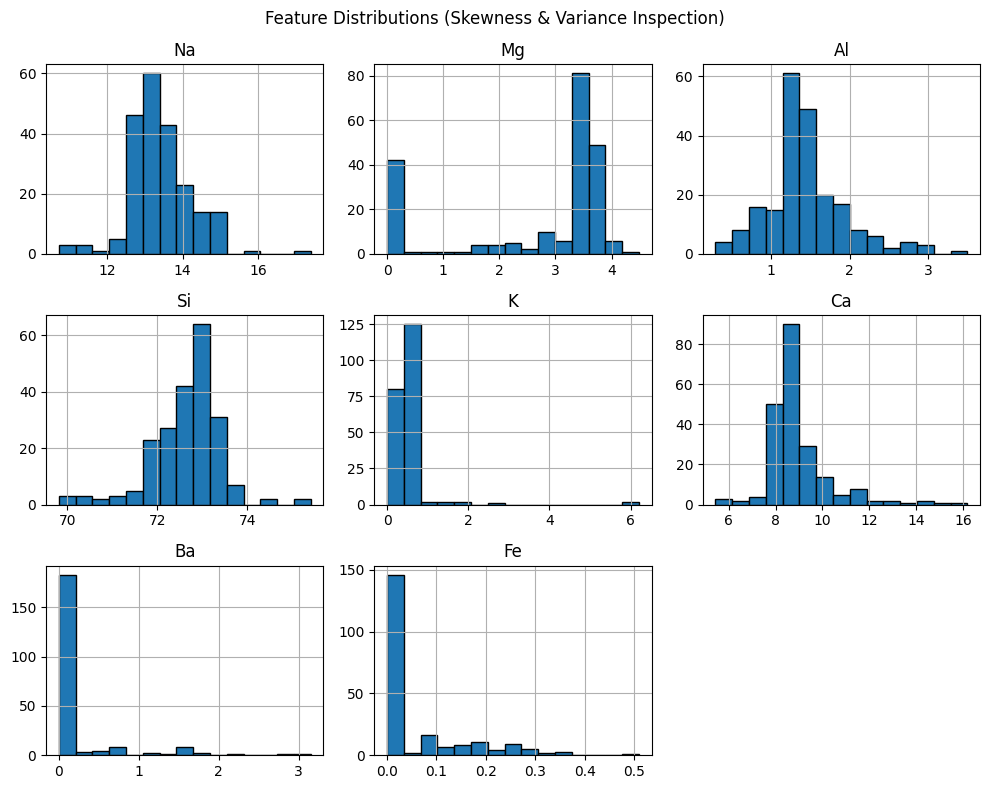

In [ ]:
df.drop(columns=['Type']).hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions (Skewness & Variance Inspection)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

# Features and target
X = df.drop(columns=['Type'])
y = df['Type']
print("Attribute Set",X.head(5))
print("Class Labels",y.head(5))

Attribute Set       Na    Mg    Al     Si     K    Ca   Ba   Fe
0  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0
Class Labels 0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded labels: ", y_encoded)
#
classes = np.unique(y_encoded)
n_classes = len(classes)
print("The number of classes in the dataset are: ", n_classes)

Encoded labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
The number of classes in the dataset are:  6


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
      )


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Binarize test targets for multi-class ROC computation
y_test_bin = label_binarize(y_test, classes=classes)


================ Random Forest ================
Accuracy: 74.07%

              precision    recall  f1-score   support

      Type 1       0.67      0.78      0.72        18
      Type 2       0.75      0.79      0.77        19
      Type 3       0.00      0.00      0.00         4
      Type 5       1.00      0.67      0.80         3
      Type 6       0.67      1.00      0.80         2
      Type 7       1.00      0.88      0.93         8

    accuracy                           0.74        54
   macro avg       0.68      0.68      0.67        54
weighted avg       0.71      0.74      0.72        54

================ k-Nearest Neighbors ================
Accuracy: 75.93%

              precision    recall  f1-score   support

      Type 1       0.76      0.72      0.74        18
      Type 2       0.73      0.84      0.78        19
      Type 3       0.33      0.25      0.29         4
      Type 5       1.00      1.00      1.00         3
      Type 6       0.50      0.50      0.50     

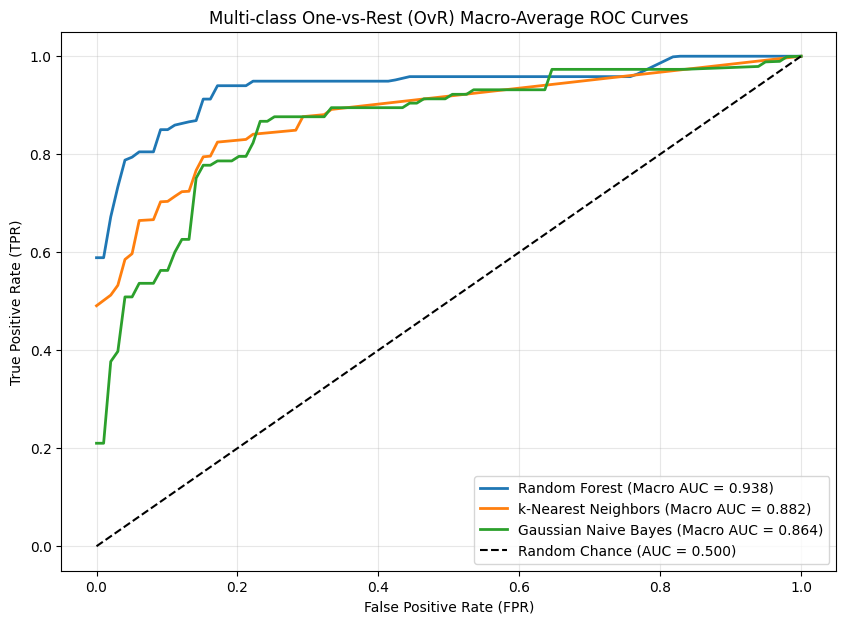

In [ ]:
# Define models
models = {
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    "k-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=3, weights='distance'), X_train_scaled, X_test_scaled),
    "Gaussian Naive Bayes": (GaussianNB(), X_train, X_test)
}

plt.figure(figsize=(10, 7))
for name, (clf, train_x, test_x) in models.items():
    # Fit model
    clf.fit(train_x, y_train)
    y_pred = clf.predict(test_x)
    y_proba = clf.predict_proba(test_x)

    # Classification Metrics
    print(f"================ {name} ================")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred, target_names=[f"Type {c}" for c in le.classes_], zero_division=0))

    # Compute Macro-Average ROC-AUC
    fpr_grid = np.linspace(0.0, 1.0, 100)
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(fpr_grid, fpr_i, tpr_i)

    mean_tpr /= n_classes
    macro_auc = auc(fpr_grid, mean_tpr)

    # Plot Macro-Average ROC Curve
    plt.plot(fpr_grid, mean_tpr, label=f"{name} (Macro AUC = {macro_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance (AUC = 0.500)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-class One-vs-Rest (OvR) Macro-Average ROC Curves")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
        classification_report,
            confusion_matrix
            )

In [ ]:
df = pd.read_csv('/content/glass.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe())

Column names:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Missing values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Duplicate rows: 1

Statistical summary:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


In [ ]:
if 'Type' not in df.columns:
      raise ValueError("Target column 'Type' not found. Check the column names printed above.")

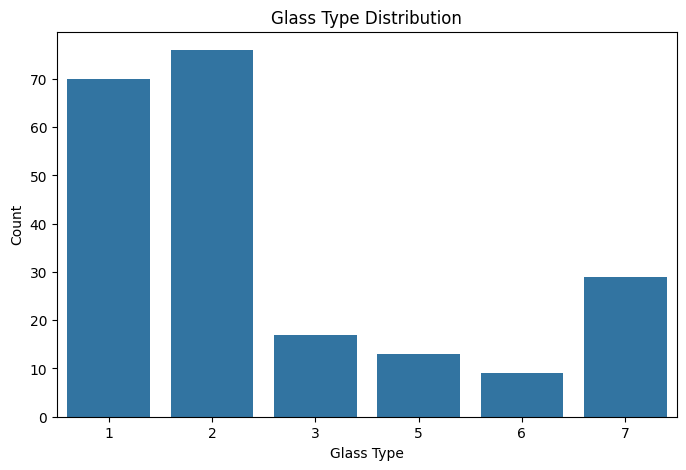

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Type', data=df)

plt.title('Glass Type Distribution')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.show()

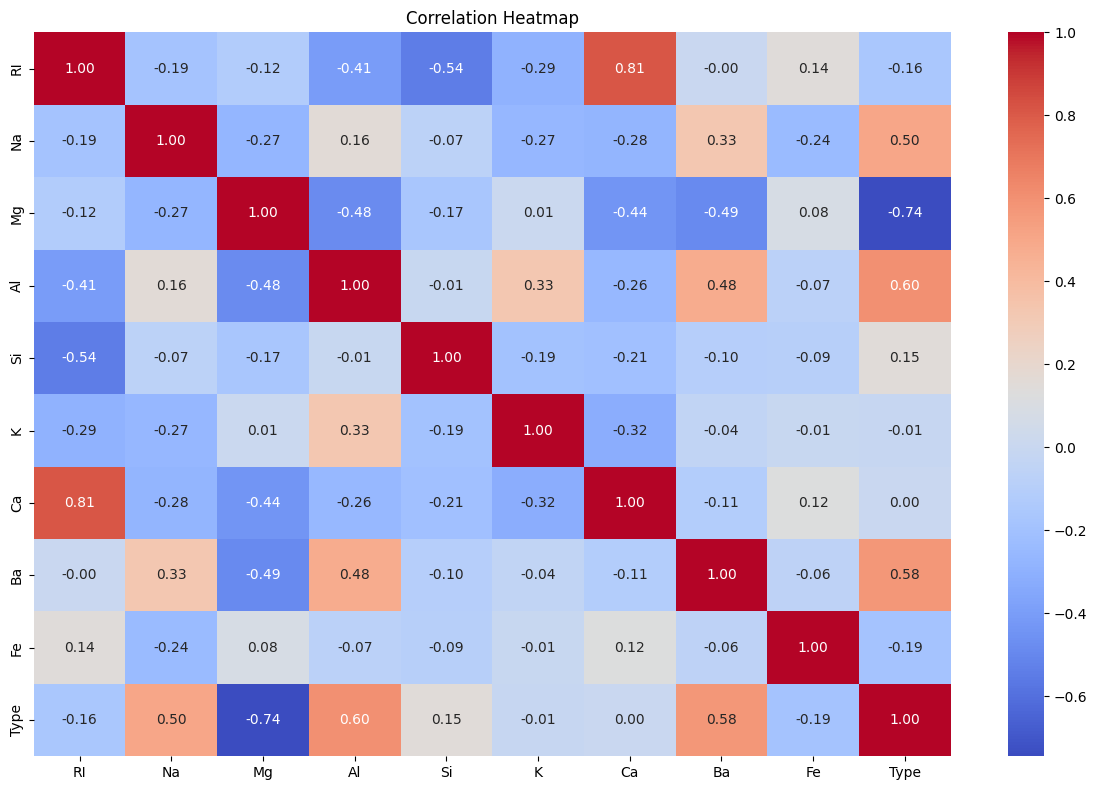

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
        annot=True,
            cmap='coolwarm',
                fmt='.2f'
                )

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

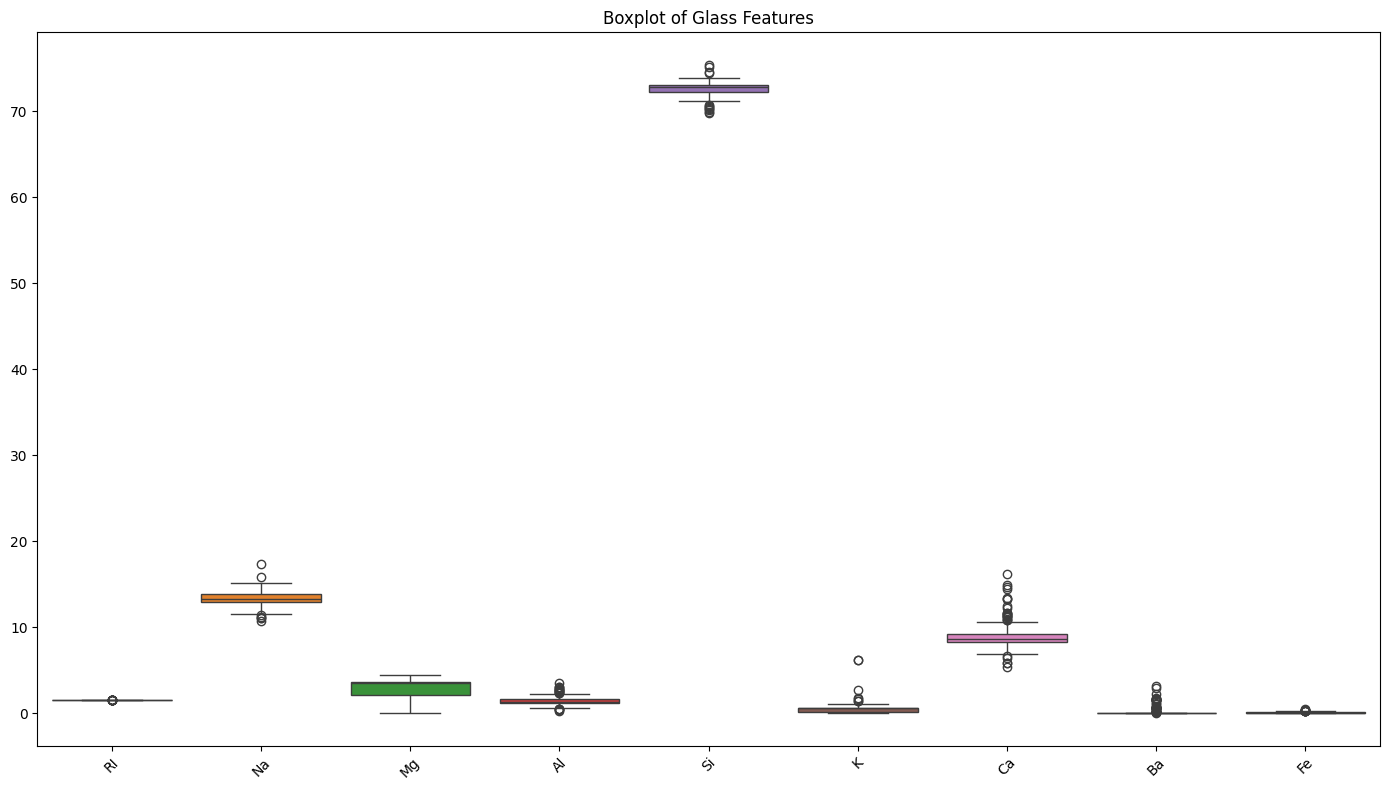

In [ ]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df.drop(columns=['Type'], errors='ignore'))

plt.title('Boxplot of Glass Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Remove ID column because it is not a useful predictive feature
X = df.drop(columns=['Type', 'Id'], errors='ignore')

# Target variable
y = df['Type']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

Target:
Type

X shape: (214, 9)
y shape: (214,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.20,
                  random_state=42,
                      stratify=y
                      )

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (171, 9)
Testing data: (43, 9)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [ ]:
knn = KNeighborsClassifier(
      n_neighbors=3,
          weights='distance'
          )

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.7906976744186046

Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.74      0.93      0.82        15
           3       1.00      0.33      0.50         3
           5       1.00      0.67      0.80         3
           6       0.50      0.50      0.50         2
           7       0.83      0.83      0.83         6

    accuracy                           0.79        43
   macro avg       0.82      0.68      0.71        43
weighted avg       0.81      0.79      0.78        43



In [ ]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Gaussian Naive Bayes Accuracy:", nb_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Gaussian Naive Bayes Accuracy: 0.5116279069767442

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.86      0.63        14
           2       0.40      0.13      0.20        15
           3       0.00      0.00      0.00         3
           5       0.50      0.33      0.40         3
           6       0.50      1.00      0.67         2
           7       0.83      0.83      0.83         6

    accuracy                           0.51        43
   macro avg       0.46      0.53      0.46        43
weighted avg       0.48      0.51      0.45        43



In [ ]:
rf = RandomForestClassifier(
      n_estimators=100,
          random_state=42
          )

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8372093023255814

Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



In [ ]:
results = pd.DataFrame({
      'Model': [
              'KNN',
                      'Gaussian Naive Bayes',
                              'Random Forest'
                                  ],
                                      'Accuracy': [
                                              knn_accuracy,
                                                      nb_accuracy,
                                                              rf_accuracy
                                                                  ]
                                                                  })

results['Accuracy (%)'] = results['Accuracy'] * 100

display(results)


,Model,Accuracy,Accuracy (%)
0,KNN,0.790698,79.069767
1,Gaussian Naive Bayes,0.511628,51.162791
2,Random Forest,0.837209,83.720930


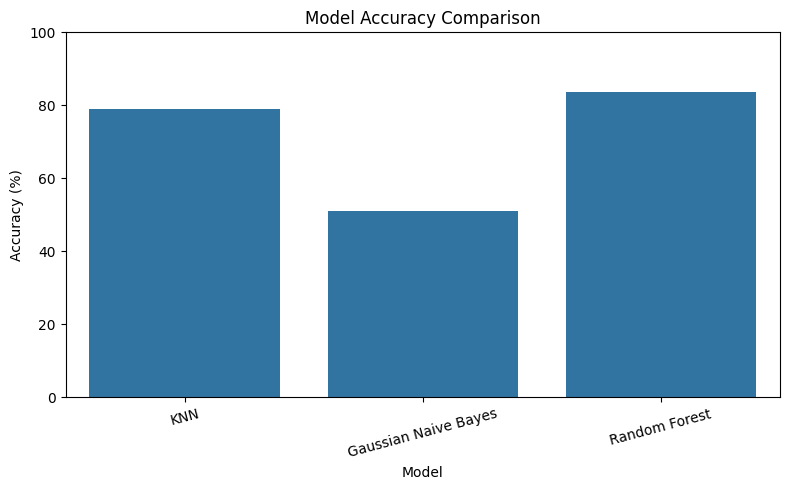

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
        y='Accuracy (%)',
            data=results
            )

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

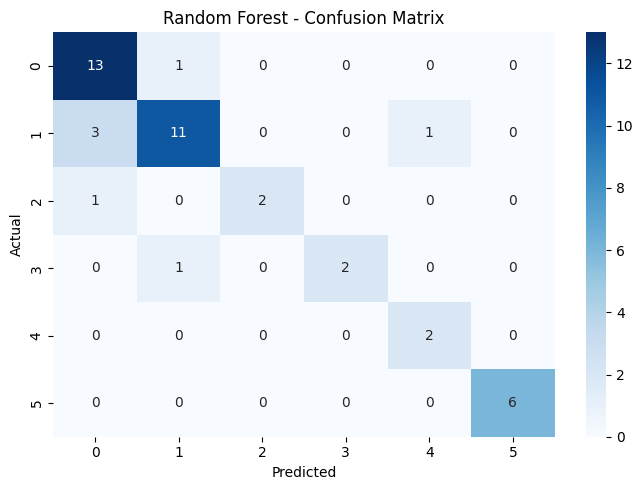

In [ ]:
models_predictions = {
      'KNN': y_pred_knn,
          'Gaussian Naive Bayes': y_pred_nb,
              'Random Forest': y_pred_rf
              }

for name, predictions in models_predictions.items():

                  cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title(f'{name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()



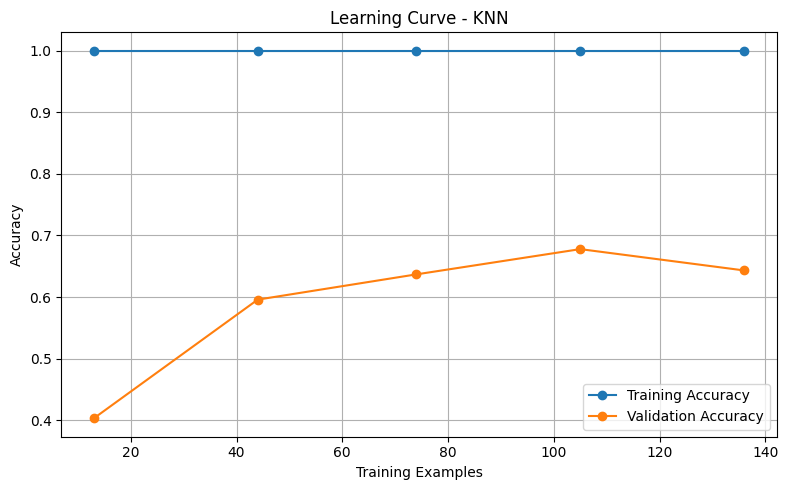

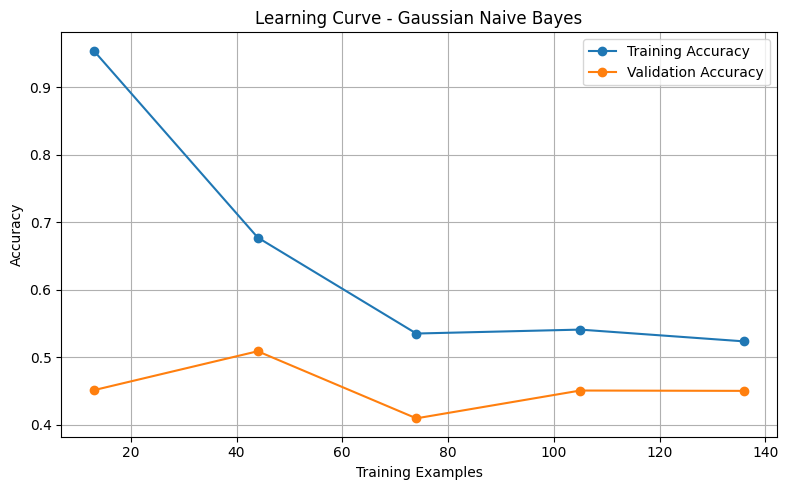

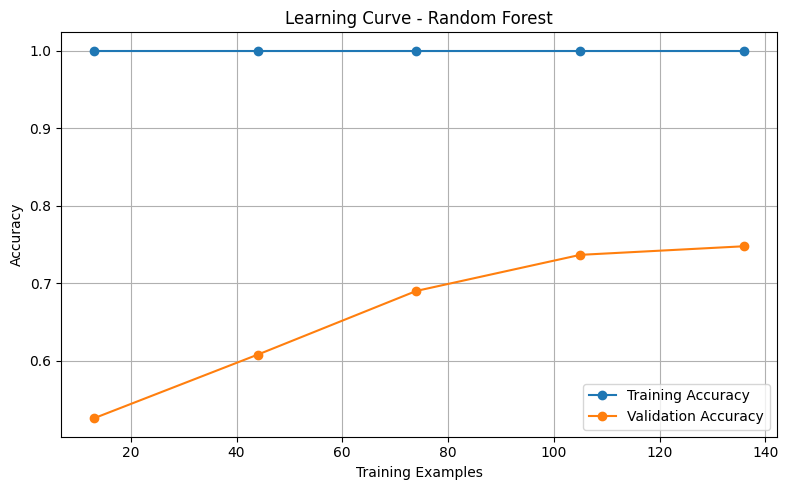

In [ ]:
cv = StratifiedKFold(
      n_splits=5,
          shuffle=True,
              random_state=42
              )

learning_models = {
                  'KNN': (
                          KNeighborsClassifier(n_neighbors=3, weights='distance'),
                                  X_train_scaled
                                      ),
                                          'Gaussian Naive Bayes': (
                                                  GaussianNB(),
                                                          X_train
                                                              ),
                                                                  'Random Forest': (
                                                                          RandomForestClassifier(
                                                                                      n_estimators=100,
                                                                                                  random_state=42
                                                                                                          ),
                                                                                                                  X_train
                                                                                                                      )
                                                                                                                      }

for name, (model, features) in learning_models.items():

    train_sizes, train_scores, validation_scores = learning_curve(
            model,
            features,
            y_train,
            cv=cv,
            scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, 5)
        )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
            train_sizes,
            train_mean,
            marker='o',
            label='Training Accuracy'
        )

    plt.plot(
            train_sizes,
            validation_mean,
            marker='o',
            label='Validation Accuracy'
        )

    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
best_model = results.loc[
      results['Accuracy'].idxmax()
      ]

print("Best Model:", best_model['Model'])
print("Best Accuracy:", round(best_model['Accuracy (%)'], 2), "%")


Best Model: Random Forest
Best Accuracy: 83.72 %
